In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random
import gsw
from sklearn.mixture import GaussianMixture
from funcs import cross_sec_lon, cross_sec_lon_prob, cross_sec_lon_prob2, calc_pv, method34

In [14]:
# Get data into dataframe
df = pd.read_csv('../../WMA_fractions_v2_with_PV.csv')

In [3]:
df.columns

Index(['Source', 'Profile_Number', 'level_2',
       'Arctic_Surface_Water_[fraction]',
       'Modified_summer_Pacific_Water_[fraction]',
       'Summer_Pacific_Water_[fraction]', 'Winter_Pacific_Water_[fraction]',
       'Norwegian_Current_Water_[fraction]', 'Atlantic_Water_[fraction]',
       'Brine-enriched_Water_[fraction]', 'Conservative_Temperature_[deg_C]',
       'Absolute_Salinity_[PSU]', 'Latitude_[deg_N]', 'Depth_[m]',
       'Longitude_[deg_E]', 'Dissolved_Oxygen_[micro_mol_per_kg]',
       'Datetime_[UTC]', 'PV', 'dPVdz'],
      dtype='str')

In [4]:
# Preprocess data to contain the relevant features
df_ST = df.copy()
df_ST = df_ST[['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]', 'Dissolved_Oxygen_[micro_mol_per_kg]', 
               'Depth_[m]', 'Latitude_[deg_N]', 'Longitude_[deg_E]','Datetime_[UTC]','Profile_Number', 'PV', 'dPVdz']]
df_ST['year'] = pd.to_datetime(df_ST['Datetime_[UTC]']).dt.year
df_ST['month'] = pd.to_datetime(df_ST['Datetime_[UTC]']).dt.month
df_ST = df_ST[df_ST['year'] >= 1980] # remove the few points before 1980 (only 7 points)
df_ST = df_ST[['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]', 'Dissolved_Oxygen_[micro_mol_per_kg]', 
               'Depth_[m]', 'Latitude_[deg_N]', 'Longitude_[deg_E]','year', 'month','Profile_Number', 'PV', 'dPVdz']]

In [5]:
# Define random master seed for reproducibility
master_seed = 22
random.seed(master_seed)

# Ensemble size
ensemble_size = 100

# Define a list of random seeds
seeds = random.sample(range(1, 10000), ensemble_size)

In [6]:
# Define features to use for clustering
features = ['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]', 'dPVdz']    

In [7]:
df_sampled = method34(df=df_ST, seed=master_seed)

In [8]:
from joblib import Parallel, delayed, cpu_count
from tqdm import tqdm
import numpy as np
import tempfile, os

# Write X to a memory-mapped temp file — workers read it directly, no copying
X = df_sampled[features].to_numpy()
tmp = tempfile.mktemp(suffix='.npy')
np.save(tmp, X)
X_memmap = np.load(tmp, mmap_mode='r')

del X  # free the in-memory copy

def fit_gmm(seed, n_components, X):
    gmm = GaussianMixture(n_components=n_components, covariance_type='full', random_state=seed)
    gmm.fit(X)
    return gmm.bic(X), gmm.aic(X)

n_components_range = range(1, 8)
total_fits = len(seeds) * len(n_components_range)
cores_used = cpu_count()

print(f"Fitting {total_fits} GMMs ({len(seeds)} seeds × {len(n_components_range)} components)")
print(f"CPU cores available: {cores_used}")
print(f"Data shape being fit: {X_memmap.shape}")
print()

try:
    results = Parallel(n_jobs=-1, backend="loky")(
        delayed(fit_gmm)(seed, n_components, X_memmap)
        for seed, n_components in tqdm(
            [(seed, n) for seed in seeds for n in n_components_range],
            total=total_fits,
            desc="Fitting GMMs",
            unit="fit"
        )
    )
finally:
    os.remove(tmp)  # always clean up temp file

# Reconstruct the same dict structure as before
all_scores = {}
all_aic_scores = {}
n = len(n_components_range)

for i in range(len(seeds)):
    chunk = results[i * n : (i + 1) * n]
    all_scores[i]     = [bic for bic, _ in chunk]
    all_aic_scores[i] = [aic for _, aic in chunk]
    
print(f"\nDone. {total_fits} fits completed.")

Fitting 35 GMMs (5 seeds × 7 components)
CPU cores available: 12
Data shape being fit: (5099277, 3)



Fitting GMMs: 100%|██████████| 35/35 [00:30<00:00,  1.14fit/s]
/Users/franciscagomes/PhD/WM_class/WaterMassClassification/.venv/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Done. 35 fits completed.


Text(0.5, 1.0, 'BIC Scores for GMM with Different Number of Components and Seeds')

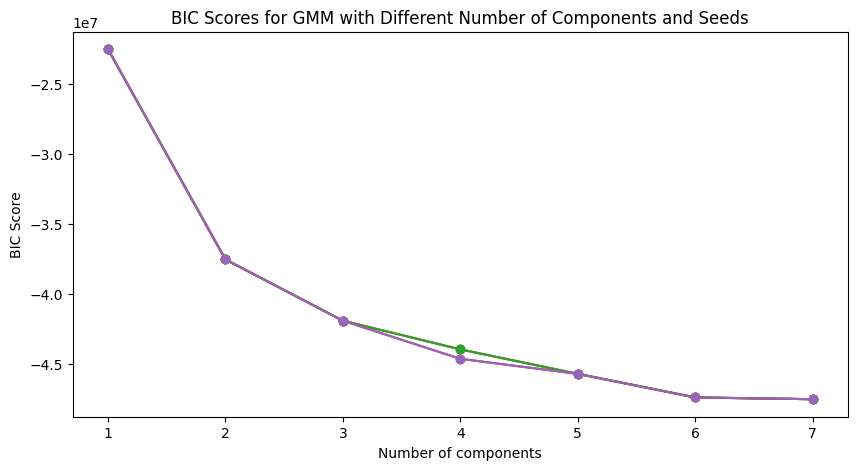

In [9]:
plt.figure(figsize=(10,5))
for i in range(ensemble_size):
    plt.plot(n_components_range, all_scores[i], label=f'Seed {seeds[i]}', marker='o')
plt.xlabel('Number of components')
plt.ylabel('BIC Score')
plt.title('BIC Scores for GMM with Different Number of Components and Seeds')

In [8]:
from joblib import Parallel, delayed, cpu_count
from tqdm import tqdm
import numpy as np
import tempfile, os

# Write X to a memory-mapped temp file — workers read it directly, no copying
X = df_sampled[features].to_numpy()
tmp = tempfile.mktemp(suffix='.npy')
np.save(tmp, X)
X_memmap = np.load(tmp, mmap_mode='r')

del X  # free the in-memory copy

def fit_gmm(seed, n_components, X):
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(X), size=500_000, replace=False)
    X_sub = X[idx]
    gmm = GaussianMixture(
        n_components=n_components,
        covariance_type='full',
        random_state=seed,
        max_iter=10_000,
        n_init=1
    )
    gmm.fit(X_sub)
    return gmm.bic(X_sub), gmm.aic(X_sub)

n_components_range = range(1, 8)
total_fits = len(seeds) * len(n_components_range)
cores_used = cpu_count()

print(f"Fitting {total_fits} GMMs ({len(seeds)} seeds × {len(n_components_range)} components)")
print(f"CPU cores available: {cores_used}")
print(f"Full data shape: {X_memmap.shape} | Subsample per fit: 100,000 rows")
print()

try:
    results = Parallel(n_jobs=-1, backend="loky")(
        delayed(fit_gmm)(seed, n_components, X_memmap)
        for seed, n_components in tqdm(
            [(seed, n) for seed in seeds for n in n_components_range],
            total=total_fits,
            desc="Fitting GMMs",
            unit="fit"
        )
    )
finally:
    os.remove(tmp)  # always clean up temp file

# Reconstruct the same dict structure as before
all_scores = {}
all_aic_scores = {}
n = len(n_components_range)

for i in range(len(seeds)):
    chunk = results[i * n : (i + 1) * n]
    all_scores[i]     = [bic for bic, _ in chunk]
    all_aic_scores[i] = [aic for _, aic in chunk]

print(f"\nDone. {total_fits} fits completed.")

Fitting 700 GMMs (100 seeds × 7 components)
CPU cores available: 12
Full data shape: (5099153, 3) | Subsample per fit: 100,000 rows



Fitting GMMs: 100%|██████████| 700/700 [29:48<00:00,  2.56s/fit]



Done. 700 fits completed.


Text(0.5, 1.0, 'BIC Scores for GMM with Different Number of Components and Seeds')

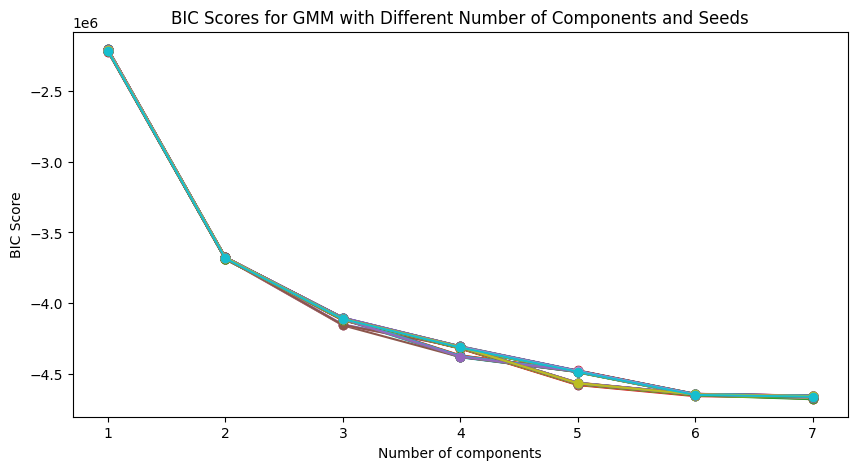

In [9]:
plt.figure(figsize=(10,5))
for i in range(ensemble_size):
    plt.plot(n_components_range, all_scores[i], label=f'Seed {seeds[i]}', marker='o')
plt.xlabel('Number of components')
plt.ylabel('BIC Score')
plt.title('BIC Scores for GMM with Different Number of Components and Seeds')

In [10]:
# Choice of optimal number of clusters based on BIC
n_clusters = 6

In [11]:
gmms = []
labels = [] 
for i,seed in enumerate(seeds):
    gmm = GaussianMixture(
        n_components=n_clusters,          # number of clusters
        covariance_type='full',  # full cov matrix has more flexibility
        random_state=seed)
    gmm.fit(df_sampled[features])
    gmms.append(gmm)
    labels.append(gmm.predict(df_sampled[features]))

In [12]:
# Preprocess for comparison of cluster labels across ensemble members,
# following Poropat et al. (2024), Sect. 2.3.
#
# Classes are matched on the CORRELATION between their D-dimensional mean
# vectors (mean T, S, depth), NOT on Euclidean distance. A cluster only
# matches an existing class if the correlation exceeds a minimal threshold
# (0.98 in the paper); otherwise it becomes a NEW reference class. This yields
# a list of reference classes that is usually longer than the per-model K,
# because some classes appear in only a few ensemble members.

MIN_CORRELATION = 0.98   # minimal correlation for matching classes (Poropat et al., 2024)

# Full D-dimensional mean vector (mean T, S, depth) of every cluster.
cluster_means = [gmms[i].means_ for i in range(ensemble_size)]

# NOTE: correlation centres each mean vector by its own across-dimension mean,
# so dimensions with very different units (T ~ °C, S ~ PSU, depth ~ m) are not
# comparable on raw values and depth would dominate. Standardise each dimension
# across all clusters first so the correlation reflects relative position in
# each variable. (In the paper the means live in EOF space, already comparable.)
all_means = np.vstack(cluster_means)
feat_mean = all_means.mean(axis=0)
feat_std  = all_means.std(axis=0)
feat_std[feat_std == 0] = 1.0
cluster_means = [(m - feat_mean) / feat_std for m in cluster_means]

def _corr(a, b):
    """Pearson correlation between two mean vectors (needs >= 3 dimensions)."""
    return np.corrcoef(np.asarray(a, float), np.asarray(b, float))[0, 1]

reference_means = []   # mean vector defining each reference class
matched_labels  = []   # per member: reference-class id of each local cluster

for i in range(ensemble_size):
    means = cluster_means[i]
    matched = np.empty(means.shape[0], dtype=int)
    for j in range(means.shape[0]):
        best_corr, best_ref = -np.inf, -1
        for r, ref in enumerate(reference_means):
            c = _corr(means[j], ref)
            if c > best_corr:
                best_corr, best_ref = c, r
        if best_ref != -1 and best_corr >= MIN_CORRELATION:
            matched[j] = best_ref                       # matches an existing class
        else:
            reference_means.append(means[j])            # no match -> new class
            matched[j] = len(reference_means) - 1
    matched_labels.append(matched)

n_reference_classes = len(reference_means)
print(f"{n_reference_classes} reference classes found across {ensemble_size} members "
      f"(K = {n_clusters} per model)")

7 reference classes found across 100 members (K = 6 per model)
